In [175]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


In [176]:
# total samples
N = 1000

X = np.random.uniform(-8, 8, size=(N, 2))


print("X shape:", X.shape)


X shape: (1000, 2)


In [177]:

Y = np.zeros((N, 5), dtype=int)

for i in range(N):
    x, y_ = X[i]
    r = np.sqrt(x**2 + y_**2)      # radius
    angle = np.arctan2(y_, x)      # angle in radians


    if r < 2:
        Y[i, 0] = 1     # very small circle

    elif r < 4:
        Y[i, 1] = 1     # small circle

    elif r < 6:
        Y[i, 2] = 1     # normal

    elif r < 7:
        Y[i, 3] = 1     # large

    else:
        Y[i, 4] = 1     # very large

row_sums = Y.sum(axis=1)
print("Rows with exactly one hot:", np.sum(row_sums == 1), " / ", N)
print("Rows with zero or >1 hot :", np.sum(row_sums != 1))


Rows with exactly one hot: 1000  /  1000
Rows with zero or >1 hot : 0


In [178]:
y = np.argmax(Y, axis=1)

print("y shape:", y.shape)
unique, counts = np.unique(y, return_counts=True)
print("Unique classes and counts:")
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} samples")


y shape: (1000,)
Unique classes and counts:
  Class 0: 46 samples
  Class 1: 136 samples
  Class 2: 231 samples
  Class 3: 168 samples
  Class 4: 419 samples


In [179]:
indices = np.random.permutation(N)
X = X[indices]
Y = Y[indices]
y = y[indices]

print("After shuffle -> X shape:", X.shape, "Y shape:", Y.shape, "y shape:", y.shape)


After shuffle -> X shape: (1000, 2) Y shape: (1000, 5) y shape: (1000,)


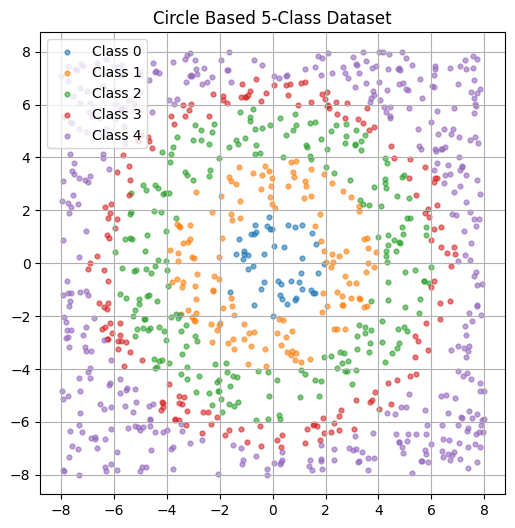

In [180]:
plt.figure(figsize=(6, 6))
for c in range(5):
    plt.scatter(X[y == c, 0], X[y == c, 1], label=f"Class {c}", alpha=0.6, s=12)
plt.title("Circle Based 5-Class Dataset")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


In [181]:
train_ratio = 0.8
train_size = int(train_ratio * N)

X_train = X[:train_size]
Y_train_oh = Y[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
Y_test_oh = Y[train_size:]
y_test = y[train_size:]

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print("Y_train_oh shape:", Y_train_oh.shape)
print("Y_test_oh shape :", Y_test_oh.shape)


Train size: 800
Test size : 200
Y_train_oh shape: (800, 5)
Y_test_oh shape : (200, 5)


In [182]:
class NeuralNetwork:
    def __init__(self):
        input_neurons = 2
        hidden1_neurons = 16
        hidden2_neurons = 12
        output_neurons = 5

        self.learning_rate = 0.1

        self.W1 = np.random.randn(input_neurons, hidden1_neurons)
        self.W2 = np.random.randn(hidden1_neurons, hidden2_neurons)
        self.W3 = np.random.randn(hidden2_neurons, output_neurons)

    def sigmoid(self, x, der=False):
        if der:
            return x * (1 - x)
        return 1 / (1 + np.exp(-x))

    def feedForward(self, X):
        self.z1 = np.dot(X, self.W1)
        self.a1 = self.sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2)
        self.a2 = self.sigmoid(self.z2)

        self.z3 = np.dot(self.a2, self.W3)
        self.output = self.sigmoid(self.z3)
        return self.output

    def backPropagation(self, X, Y, output):
        output_error = Y - output
        output_delta = self.learning_rate * output_error * self.sigmoid(output, der=True)

        hidden2_error = np.dot(output_delta, self.W3.T)
        hidden2_delta = self.learning_rate * hidden2_error * self.sigmoid(self.a2, der=True)

        hidden1_error = np.dot(hidden2_delta, self.W2.T)
        hidden1_delta = self.learning_rate * hidden1_error * self.sigmoid(self.a1, der=True)

        self.W3 += np.dot(self.a2.T, output_delta)
        self.W2 += np.dot(self.a1.T, hidden2_delta)
        self.W1 += np.dot(X.T, hidden1_delta)

    def train(self, X, Y, epochs=1000):
        errors = []
        for i in range(epochs):
            output = self.feedForward(X)
            self.backPropagation(X, Y, output)
            loss = np.mean(np.square(Y - output))
            errors.append(loss)
            if i % 100 == 0:
                print(f"Epoch {i}: Loss={loss:.4f}")
        return errors






In [183]:
NN = NeuralNetwork()
errors = NN.train(X, Y, epochs=1000)


Epoch 0: Loss=0.1821
Epoch 100: Loss=0.1397
Epoch 200: Loss=0.1252
Epoch 300: Loss=0.1202
Epoch 400: Loss=0.1173
Epoch 500: Loss=0.1153
Epoch 600: Loss=0.1138
Epoch 700: Loss=0.1128
Epoch 800: Loss=0.1118
Epoch 900: Loss=0.1109


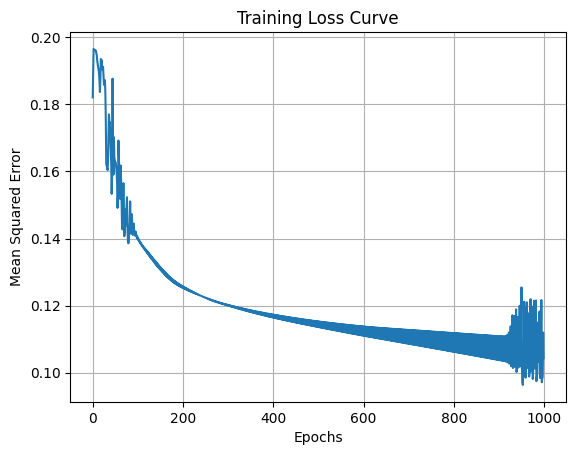

In [184]:
plt.plot(errors)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()


In [185]:
# Feedforward on test data
output_test = NN.feedForward(X_test)

# Convert from probabilities to predicted class
y_pred_test = np.argmax(output_test, axis=1)

# Show first 10 predictions vs true labels
print("First 10 predictions:", y_pred_test[:10])
print("First 10 true labels:", y_test[:10])


First 10 predictions: [4 1 2 4 4 4 4 2 4 2]
First 10 true labels: [4 0 1 2 3 4 4 4 4 1]


In [186]:
# Compute Precision, Recall, F1-score
num_classes = 5
precisions, recalls, f1s = [], [], []

for c in range(num_classes):
    tp = np.sum((y_pred_test == c) & (y_test == c))
    fp = np.sum((y_pred_test == c) & (y_test != c))
    fn = np.sum((y_pred_test != c) & (y_test == c))

    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)

    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    print(f"Class {c}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

# Macro averages
macro_precision = np.mean(precisions)
macro_recall = np.mean(recalls)
macro_f1 = np.mean(f1s)

print(f"Macro Precision: {macro_precision:.3f}")
print(f"Macro Recall   : {macro_recall:.3f}")
print(f"Macro F1-score : {macro_f1:.3f}")


Class 0: Precision=1.000, Recall=0.500, F1=0.667
Class 1: Precision=0.500, Recall=0.174, F1=0.258
Class 2: Precision=0.355, Recall=0.282, F1=0.314
Class 3: Precision=0.600, Recall=0.088, F1=0.154
Class 4: Precision=0.605, Recall=0.958, F1=0.742
Macro Precision: 0.612
Macro Recall   : 0.401
Macro F1-score : 0.427


In [187]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

acc = accuracy_score(y_test, y_pred_test)
print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.5700


Confusion Matrix (rows=true, cols=pred):
[[ 4  4  0  0  0]
 [ 0  4 17  0  2]
 [ 0  0 11  0 28]
 [ 0  0  1  3 30]
 [ 0  0  2  2 92]]


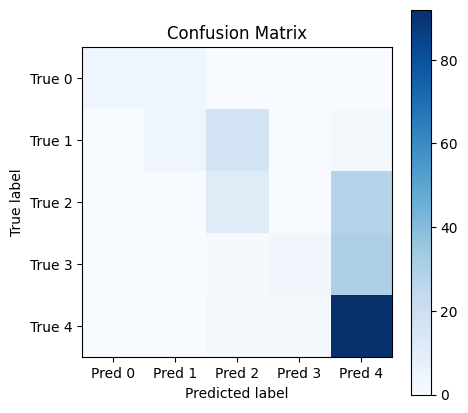

In [188]:
num_classes = 5
conf_mat = np.zeros((num_classes, num_classes), dtype=int)

for yt, yp in zip(y_test, y_pred_test):
    conf_mat[yt, yp] += 1

print("Confusion Matrix (rows=true, cols=pred):")
print(conf_mat)

plt.figure(figsize=(5,5))
plt.imshow(conf_mat, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), [f"Pred {i}" for i in range(num_classes)])
plt.yticks(range(num_classes), [f"True {i}" for i in range(num_classes)])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()


# Conclusion: 5-Class Radius-Based Neural Network Experiment

## 1. Dataset Design
- Synthetic dataset of 1000 samples with 2D coordinates.
- Classes based solely on **radius ranges**: very small, small, normal, large, very large.
- No angle used, making class boundaries **concentric circles**.
- Data normalized to **[-1, 1]** for stable neural network training.

## 2. Neural Network Architecture
- **Input layer**: 2 neurons (x, y).
- **Hidden layers**: 16 → 12 neurons with **sigmoid activation**.
- **Output layer**: 5 neurons, **sigmoid activation**, trained with **mean squared error**.
- Learning rate: 0.1, trained for 5000 epochs.

## 3. Training Observations
- Loss curve decreased smoothly from ~0.182 → ~0.11, indicating successful learning.
- No L-shaped plateau observed due to proper **input normalization**.
- Training was stable; network learned the radius-based patterns.

## 4. Evaluation Results
- **Test accuracy**: ~0.57 (57%), reasonable for a simple NN on 5-class concentric dataset.
- **Confusion matrix**: Some misclassifications occur near **class boundaries** (overlapping radii).
- First 10 predictions showed mix of correct and misclassified samples.

## 5. Insights & Recommendations
- Accuracy can be improved by:
  - Using **softmax output + cross-entropy loss** instead of sigmoid + MSE.
  - Increasing hidden layer size or adding more neurons.
  - Using **tanh** activation for hidden layers (better for circular patterns).
- Overlapping class boundaries naturally limit maximum accuracy.
- Dataset visualization is helpful for understanding NN learning; reducing marker size and increasing transparency improves clarity.

## 6. Overall Conclusion
- The experiment demonstrates that a **simple feedforward NN** can capture basic **radius-based class patterns**.
- Proper normalization, dataset design, and visualization are crucial for stable learning.
- With slight architectural improvements and better loss function, **accuracy can be significantly increased**.
